# Customer Lifetime Value & RFM Analysis using Machine Learning

Dataset collected from : https://github.com/Naveenprabaharan/Customer-Lifetime-Value-RFM-Analysis-

This notebook explores different Machine learning experiments over CLF & RFM analysis

In [49]:
#Use As required to install libraries
# !pip install plydata
# !pip install plotnine
# !pip install pandas
# !pip install numpy

In [50]:
# importing package
import pandas as pd
import numpy as np
import joblib
import plydata.cat_tools as cat
import plotnine as pn

pn.options.dpi=300
# from xgboost import XBClassifier, XGBRegressor
from sklearn.model_selection import GridSearchCV

# 1. Data Preparation

In [51]:
raw_data = pd.read_csv('datasets/CDNOW_master.txt',sep='\s+')
raw_data.columns = ['customer_id','date','quantity','price']
raw_data.head()

,customer_id,date,quantity,price
0,2,19970112,1,12.00
1,2,19970112,5,77.00
2,3,19970102,2,20.76
3,3,19970330,2,20.76
4,3,19970402,2,19.54


In [52]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69658 entries, 0 to 69657
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  69658 non-null  int64  
 1   date         69658 non-null  int64  
 2   quantity     69658 non-null  int64  
 3   price        69658 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 2.1 MB


In [53]:
raw_data.isnull().sum()

customer_id    0
date           0
quantity       0
price          0
dtype: int64

In [54]:
type(raw_data['date'])

pandas.core.series.Series

In [55]:
raw_data['date'] = raw_data['date'].astype('str') #converting to string 
raw_data['date'] = pd.to_datetime(raw_data['date'],format='%Y%m%d') # converting into datetime

In [56]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69658 entries, 0 to 69657
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  69658 non-null  int64         
 1   date         69658 non-null  datetime64[ns]
 2   quantity     69658 non-null  int64         
 3   price        69658 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 2.1 MB


## 2. Cohort Analysis

In [57]:
# taking first occuarnce of customer

first_purchase = raw_data.sort_values(by=['customer_id','date']).groupby(['customer_id']).first()
print(first_purchase)

                  date  quantity  price
customer_id                            
2           1997-01-12         1  12.00
3           1997-01-02         2  20.76
4           1997-01-01         2  29.33
5           1997-01-01         2  29.33
6           1997-01-01         1  20.99
...                ...       ...    ...
23566       1997-03-25         2  36.00
23567       1997-03-25         1  20.97
23568       1997-03-25         1  22.97
23569       1997-03-25         2  25.74
23570       1997-03-25         3  51.12

[23569 rows x 3 columns]


In [58]:
# finding min and max day
min_day = raw_data['date'].min()
print('min_day : ',min_day)

max_day = raw_data['date'].max()
print('max_day : ',max_day)

totalday = max_day - min_day
print("totalday : ",totalday)
print(int(totalday.days / 30.44)) #in month

min_day :  1997-01-01 00:00:00
max_day :  1998-06-30 00:00:00
totalday :  545 days 00:00:00
17


### Visualize all purchase

<Axes: xlabel='date'>

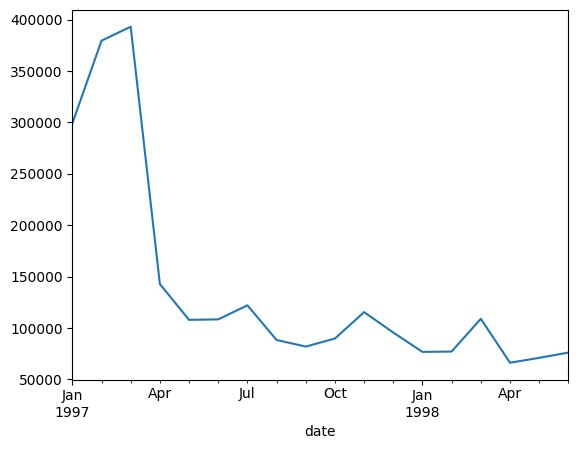

In [59]:
raw_data.reset_index().set_index('date')['price'].resample(rule="MS").sum().plot()
# clear index reset_index
# set index as date - set_index('date')
# need only price - ['price']
# based on month grouping - resample(rule="MS")
# sum() adding amount - sum()
# plot - plot()

### Visualize individual customer purchase

In [60]:
unique_id = raw_data['customer_id'].unique() # picking unique ID
ids_selected = unique_id[0:10] #selectig 10 id

#subset of unique customer purchase details
subset_raw_data = raw_data[raw_data['customer_id'].isin(ids_selected)].groupby(['customer_id','date']).sum().reset_index()
subset_raw_data

,customer_id,date,quantity,price
0,2,1997-01-12,6,89.00
1,3,1997-01-02,2,20.76
2,3,1997-03-30,2,20.76
3,3,1997-04-02,2,19.54
4,3,1997-11-15,5,57.45
5,3,1997-11-25,4,20.96
6,3,1998-05-28,1,16.99
7,4,1997-01-01,2,29.33
8,4,1997-01-18,2,29.73
9,4,1997-08-02,1,14.96


c:\Users\saila\AppData\Local\Programs\Python\Python310\lib\site-packages\mizani\breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")
c:\Users\saila\AppData\Local\Programs\Python\Python310\lib\site-packages\plotnine\geoms\geom_path.py:113: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?
c:\Users\saila\AppData\Local\Programs\Python\Python310\lib\site-packages\plotnine\geoms\geom_path.py:113: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?
c:\Users\saila\AppData\Local\Programs\Python\Python310\lib\site-packages\plotnine\geoms\geom_path.py:113: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


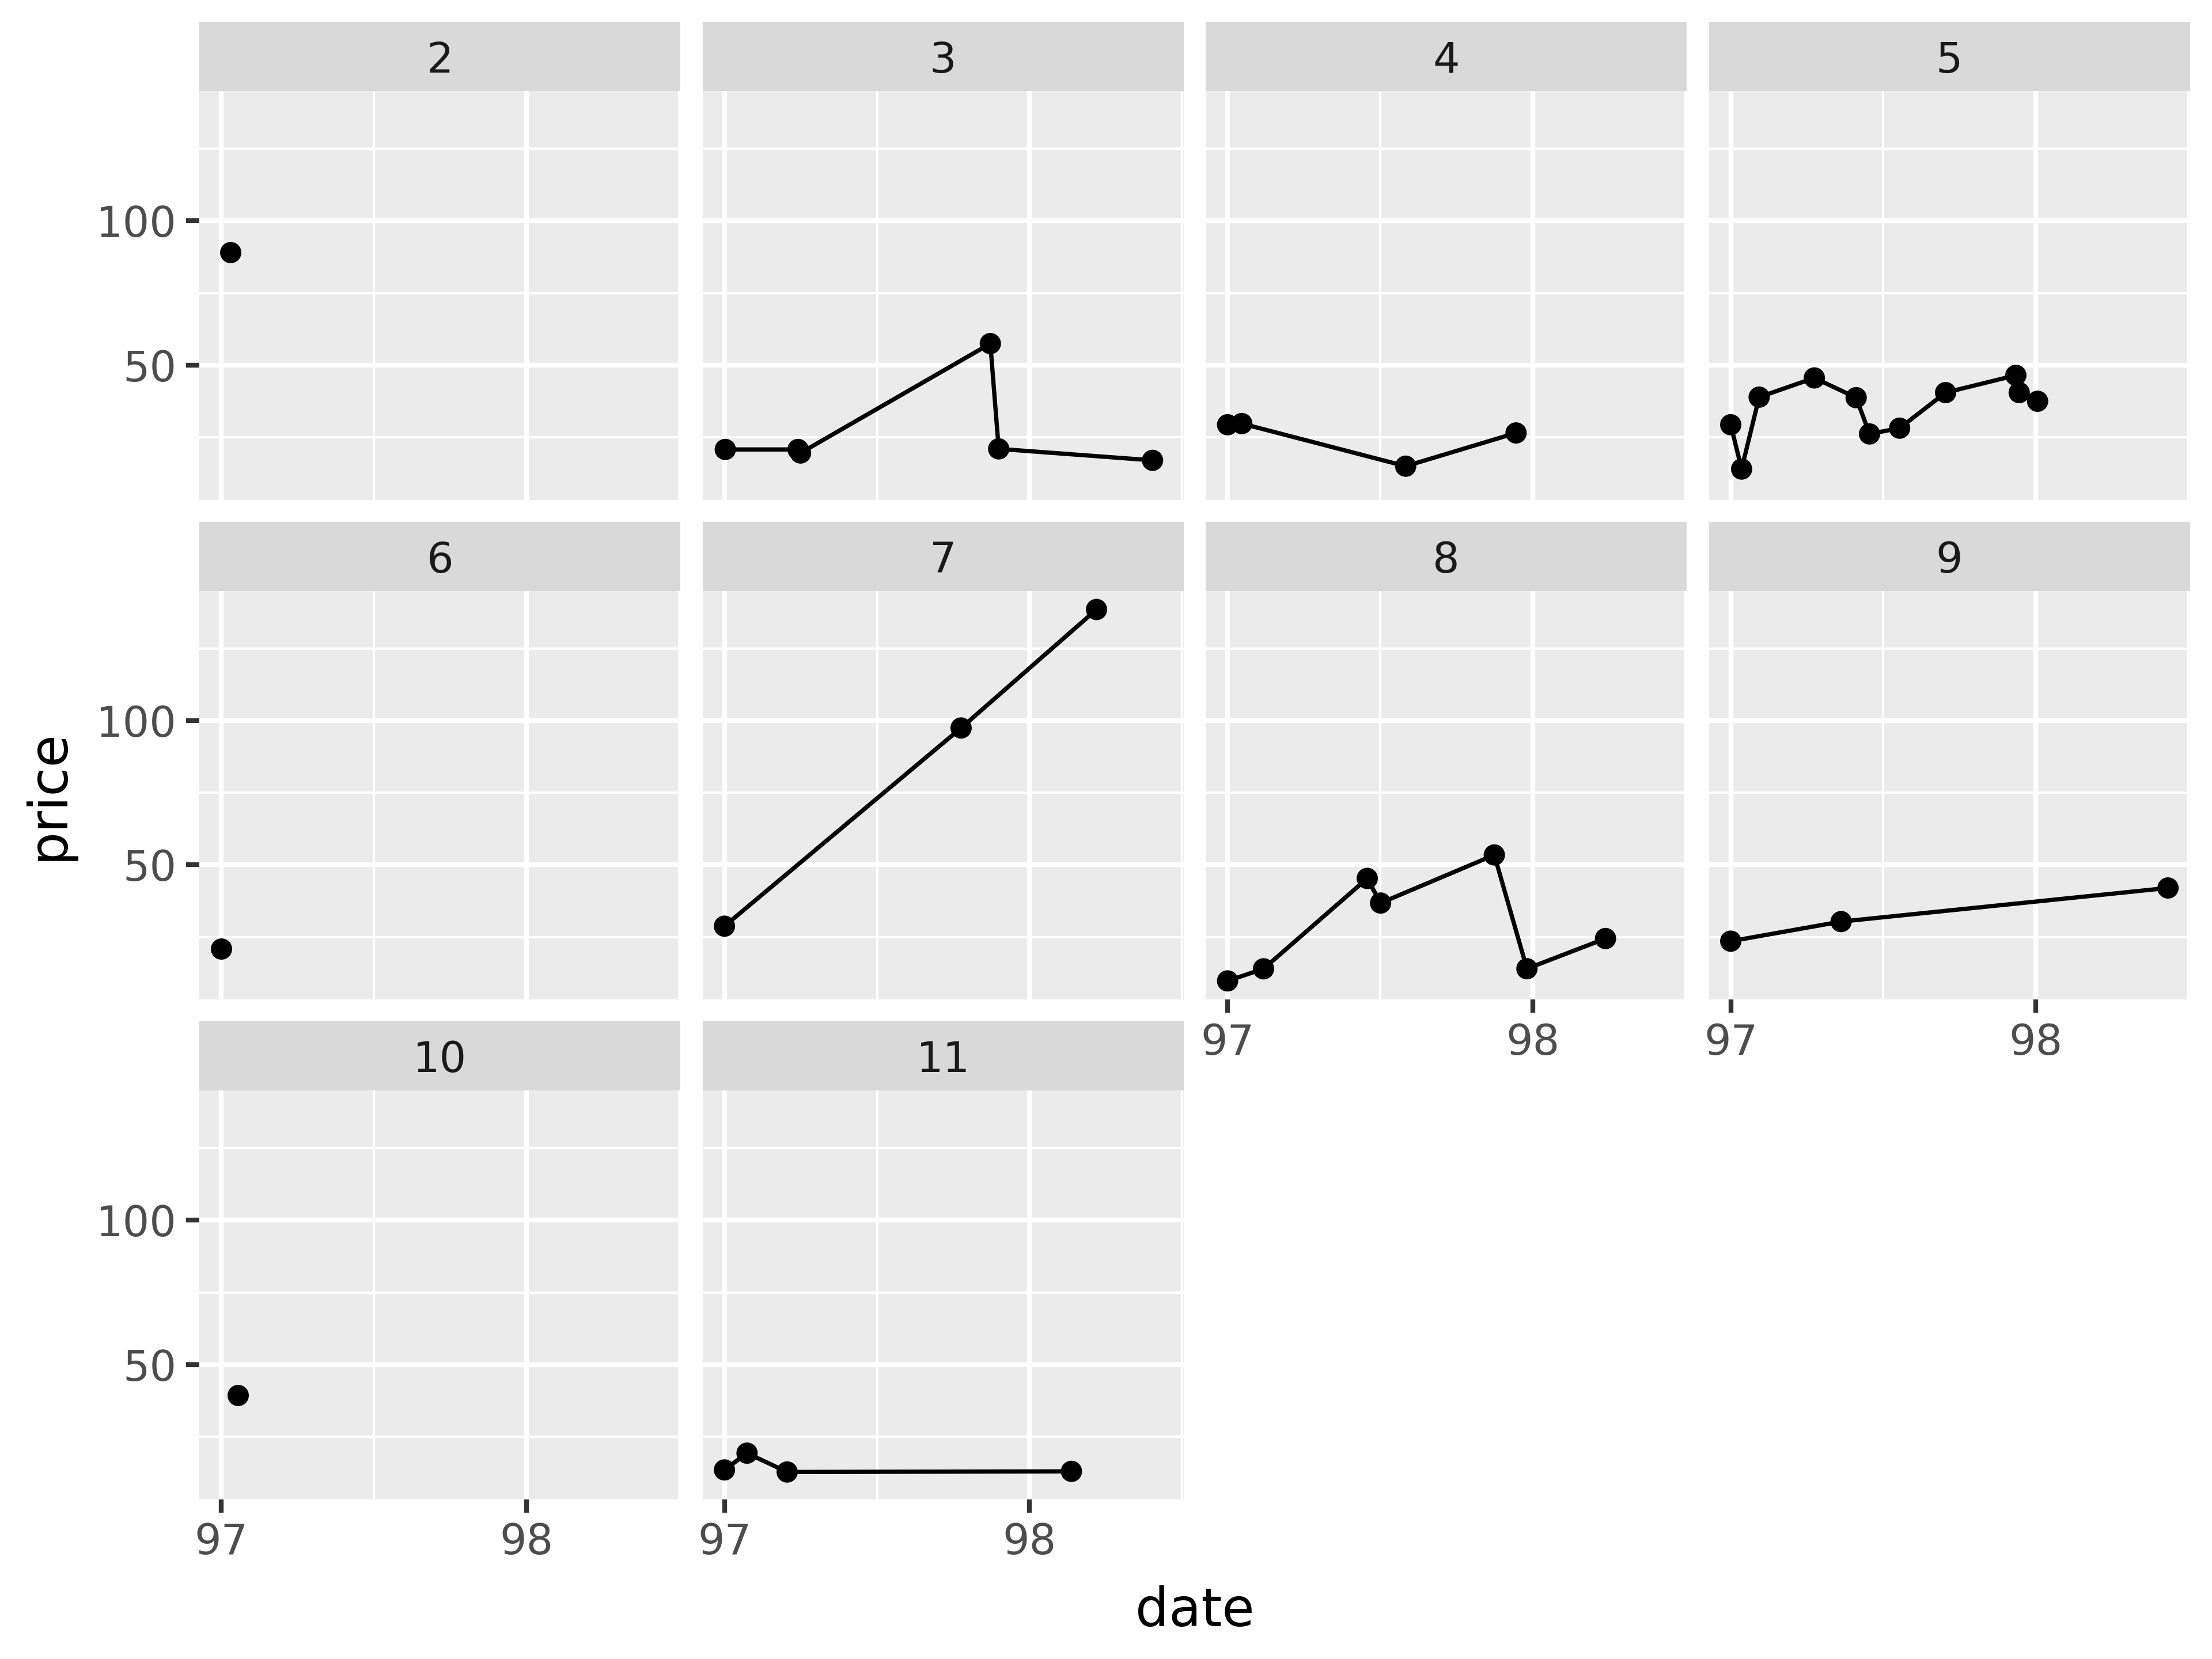

In [61]:
# ploting customer purchase detailas
pn.ggplot(subset_raw_data, pn.aes("date","price",group='customer_id'))+pn.geom_line()+pn.geom_point()+pn.facet_wrap('customer_id')+pn.scale_x_date(date_breaks="1 year",date_labels='%y')

## 3. Machine Learning
#### Frame the problem:
###### 1.what will the customer spent in next 90 days (Regression)
###### 2.What is the probability of customer to make purchase in next 90 days?

In [62]:
# Time split

n_days = 90
max_day = raw_data['date'].max()
cutoff_day = max_day - pd.to_timedelta(n_days,unit='d')
print(cutoff_day)

temporal_in_df = raw_data[raw_data['date'] <= cutoff_day]
temporal_out_df = raw_data[raw_data['date'] > cutoff_day]
print(temporal_in_df)
print(temporal_out_df)

1998-04-01 00:00:00
       customer_id       date  quantity  price
0                2 1997-01-12         1  12.00
1                2 1997-01-12         5  77.00
2                3 1997-01-02         2  20.76
3                3 1997-03-30         2  20.76
4                3 1997-04-02         2  19.54
...            ...        ...       ...    ...
69653        23568 1997-04-05         4  83.74
69654        23568 1997-04-22         1  14.99
69655        23569 1997-03-25         2  25.74
69656        23570 1997-03-25         3  51.12
69657        23570 1997-03-26         2  42.96

[63798 rows x 4 columns]
       customer_id       date  quantity  price
7                3 1998-05-28         1  16.99
37               9 1998-06-08         2  41.98
67              25 1998-04-17         1  12.99
68              25 1998-05-25         1  10.49
69              25 1998-06-03         3  24.97
...            ...        ...       ...    ...
69582        23534 1998-05-02         1  10.48
69622        2

In [63]:
# make target from out data

target_df = temporal_out_df.drop(['quantity','date'],axis=1).groupby(['customer_id']).sum().rename({'price':"spent_90_days"},axis=1).assign(spent_90_flag=1)
target_df

,spent_90_days,spent_90_flag
customer_id,,
3,16.99,1
9,41.98,1
25,73.43,1
29,48.45,1
31,117.99,1
...,...,...
23529,40.56,1
23534,10.48,1
23555,77.44,1


In [64]:
# create Recency feature

max_day = temporal_in_df['date'].max()
print("max day = ",max_day)
recency_df = temporal_in_df[['customer_id','date']].groupby('customer_id').apply(lambda x : (x['date'].max() - max_day) / pd.to_timedelta(1,'day')).to_frame().set_axis(['recency'],axis=1)
recency_df


max day =  1998-04-01 00:00:00


C:\Users\saila\AppData\Local\Temp\ipykernel_51532\2597216597.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,recency
customer_id,
2,-444.0
3,-127.0
4,-110.0
5,-88.0
6,-455.0
...,...
23566,-372.0
23567,-372.0
23568,-344.0


In [65]:
# create frequency feature

frequency_df = temporal_in_df[['customer_id','date']].groupby('customer_id').count().set_axis(['fequency'],axis=1)
frequency_df

,fequency
customer_id,
2,2
3,5
4,4
5,11
6,1
...,...
23566,1
23567,1
23568,3


In [66]:
# create Monetory feature

monetory_df = temporal_in_df[['customer_id','price']].groupby('customer_id').aggregate({'price':{'sum','mean'}}).set_axis(['price_sum','price_mean'],axis=1)
monetory_df

,price_sum,price_mean
customer_id,,
2,89.00,44.500000
3,139.47,27.894000
4,100.50,25.125000
5,385.61,35.055455
6,20.99,20.990000
...,...,...
23566,36.00,36.000000
23567,20.97,20.970000
23568,121.70,40.566667


In [67]:
# combine features

feature_df = pd.concat([recency_df,frequency_df,monetory_df],axis=1).merge(
target_df,
left_index=True,
right_index=True,
how='left').fillna(0)


feature_df

,recency,fequency,price_sum,price_mean,spent_90_days,spent_90_flag
customer_id,,,,,,
2,-444.0,2,89.00,44.500000,0.00,0.0
3,-127.0,5,139.47,27.894000,16.99,1.0
4,-110.0,4,100.50,25.125000,0.00,0.0
5,-88.0,11,385.61,35.055455,0.00,0.0
6,-455.0,1,20.99,20.990000,0.00,0.0
...,...,...,...,...,...,...
23566,-372.0,1,36.00,36.000000,0.00,0.0
23567,-372.0,1,20.97,20.970000,0.00,0.0
23568,-344.0,3,121.70,40.566667,0.00,0.0


In [68]:
#!pip install xgboost

  ## 4. Machine Learning

### i.Regression Model

In [69]:
from xgboost import XGBClassifier,XGBRegressor
from sklearn.model_selection import GridSearchCV

In [70]:
# spent next 90 days prediction

X = feature_df[['recency','fequency','price_sum','price_mean']]
y_spend = feature_df[['spent_90_days']]

#define reg spec
xgb_reg_spec = XGBRegressor(objective="reg:squarederror",random_state=123)

# model build
xgb_reg_model = GridSearchCV(estimator=xgb_reg_spec , param_grid=dict(learning_rate=[0.01,0.1,0.3,0.5]),
                             scoring='neg_mean_absolute_error',
                            refit=True,
                            cv=5)


In [71]:
# model trining
xgb_reg_model.fit(X,y_spend) 

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.3, 0.5]},
             scoring='neg_mean_absolute_error')

In [72]:
print(xgb_reg_model.best_score_)
print(xgb_reg_model.best_params_)
print(xgb_reg_model.best_estimator_)

-11.093881120523914
{'learning_rate': 0.1}
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


In [73]:
prediction_reg = xgb_reg_model.predict(X)
prediction_reg

array([ 1.922816 , 13.238541 , 10.413027 , ...,  4.4216275,  1.1352314,
        3.3022094], dtype=float32)

### ii.Classification Model

In [74]:
#define clssifi output
y_prob = feature_df[['spent_90_flag']]

# define model spec
xgb_cla_spc = XGBClassifier(objective='binary:logistic',random_state=123)

#define model
xgb_cla_model = GridSearchCV(estimator = xgb_cla_spc, param_grid=dict(learning_rate=[0.01,0.1,0.3,0.5]),scoring='roc_auc',refit=True,cv=5)

In [75]:
xgb_cla_model.fit(X,y_prob)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.3, 0.5]},
             scoring='roc_auc')

In [76]:
print(xgb_cla_model.best_score_)
print(xgb_cla_model.best_params_)
print(xgb_cla_model.best_estimator_)

0.8342796056930972
{'learning_rate': 0.01}
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


In [77]:
prediction_claf = xgb_cla_model.predict_proba(X)
prediction_claf

array([[0.9389497 , 0.06105028],
       [0.77825093, 0.22174904],
       [0.77976465, 0.22023532],
       ...,
       [0.872675  , 0.12732498],
       [0.92640156, 0.07359843],
       [0.9026498 , 0.0973502 ]], dtype=float32)

## Feature Importances

In [78]:
# importancetnace | Spent Amount model
imp_amnt_spent_dict = xgb_reg_model.best_estimator_.get_booster().get_score(importance_type='gain')
print(imp_amnt_spent_dict)

importancetnace_xgb_reg_model_df = pd.DataFrame(
    data={
    'feature':list(imp_amnt_spent_dict.keys()),
    'values':list(imp_amnt_spent_dict.values())
}).assign(feature = lambda x : cat.cat_reorder(x['feature'],x['values']))
print(importancetnace_xgb_reg_model_df)

{'recency': 26198.93359375, 'fequency': 71291.4140625, 'price_sum': 156054.078125, 'price_mean': 30069.5234375}
      feature         values
0     recency   26198.933594
1    fequency   71291.414062
2   price_sum  156054.078125
3  price_mean   30069.523438


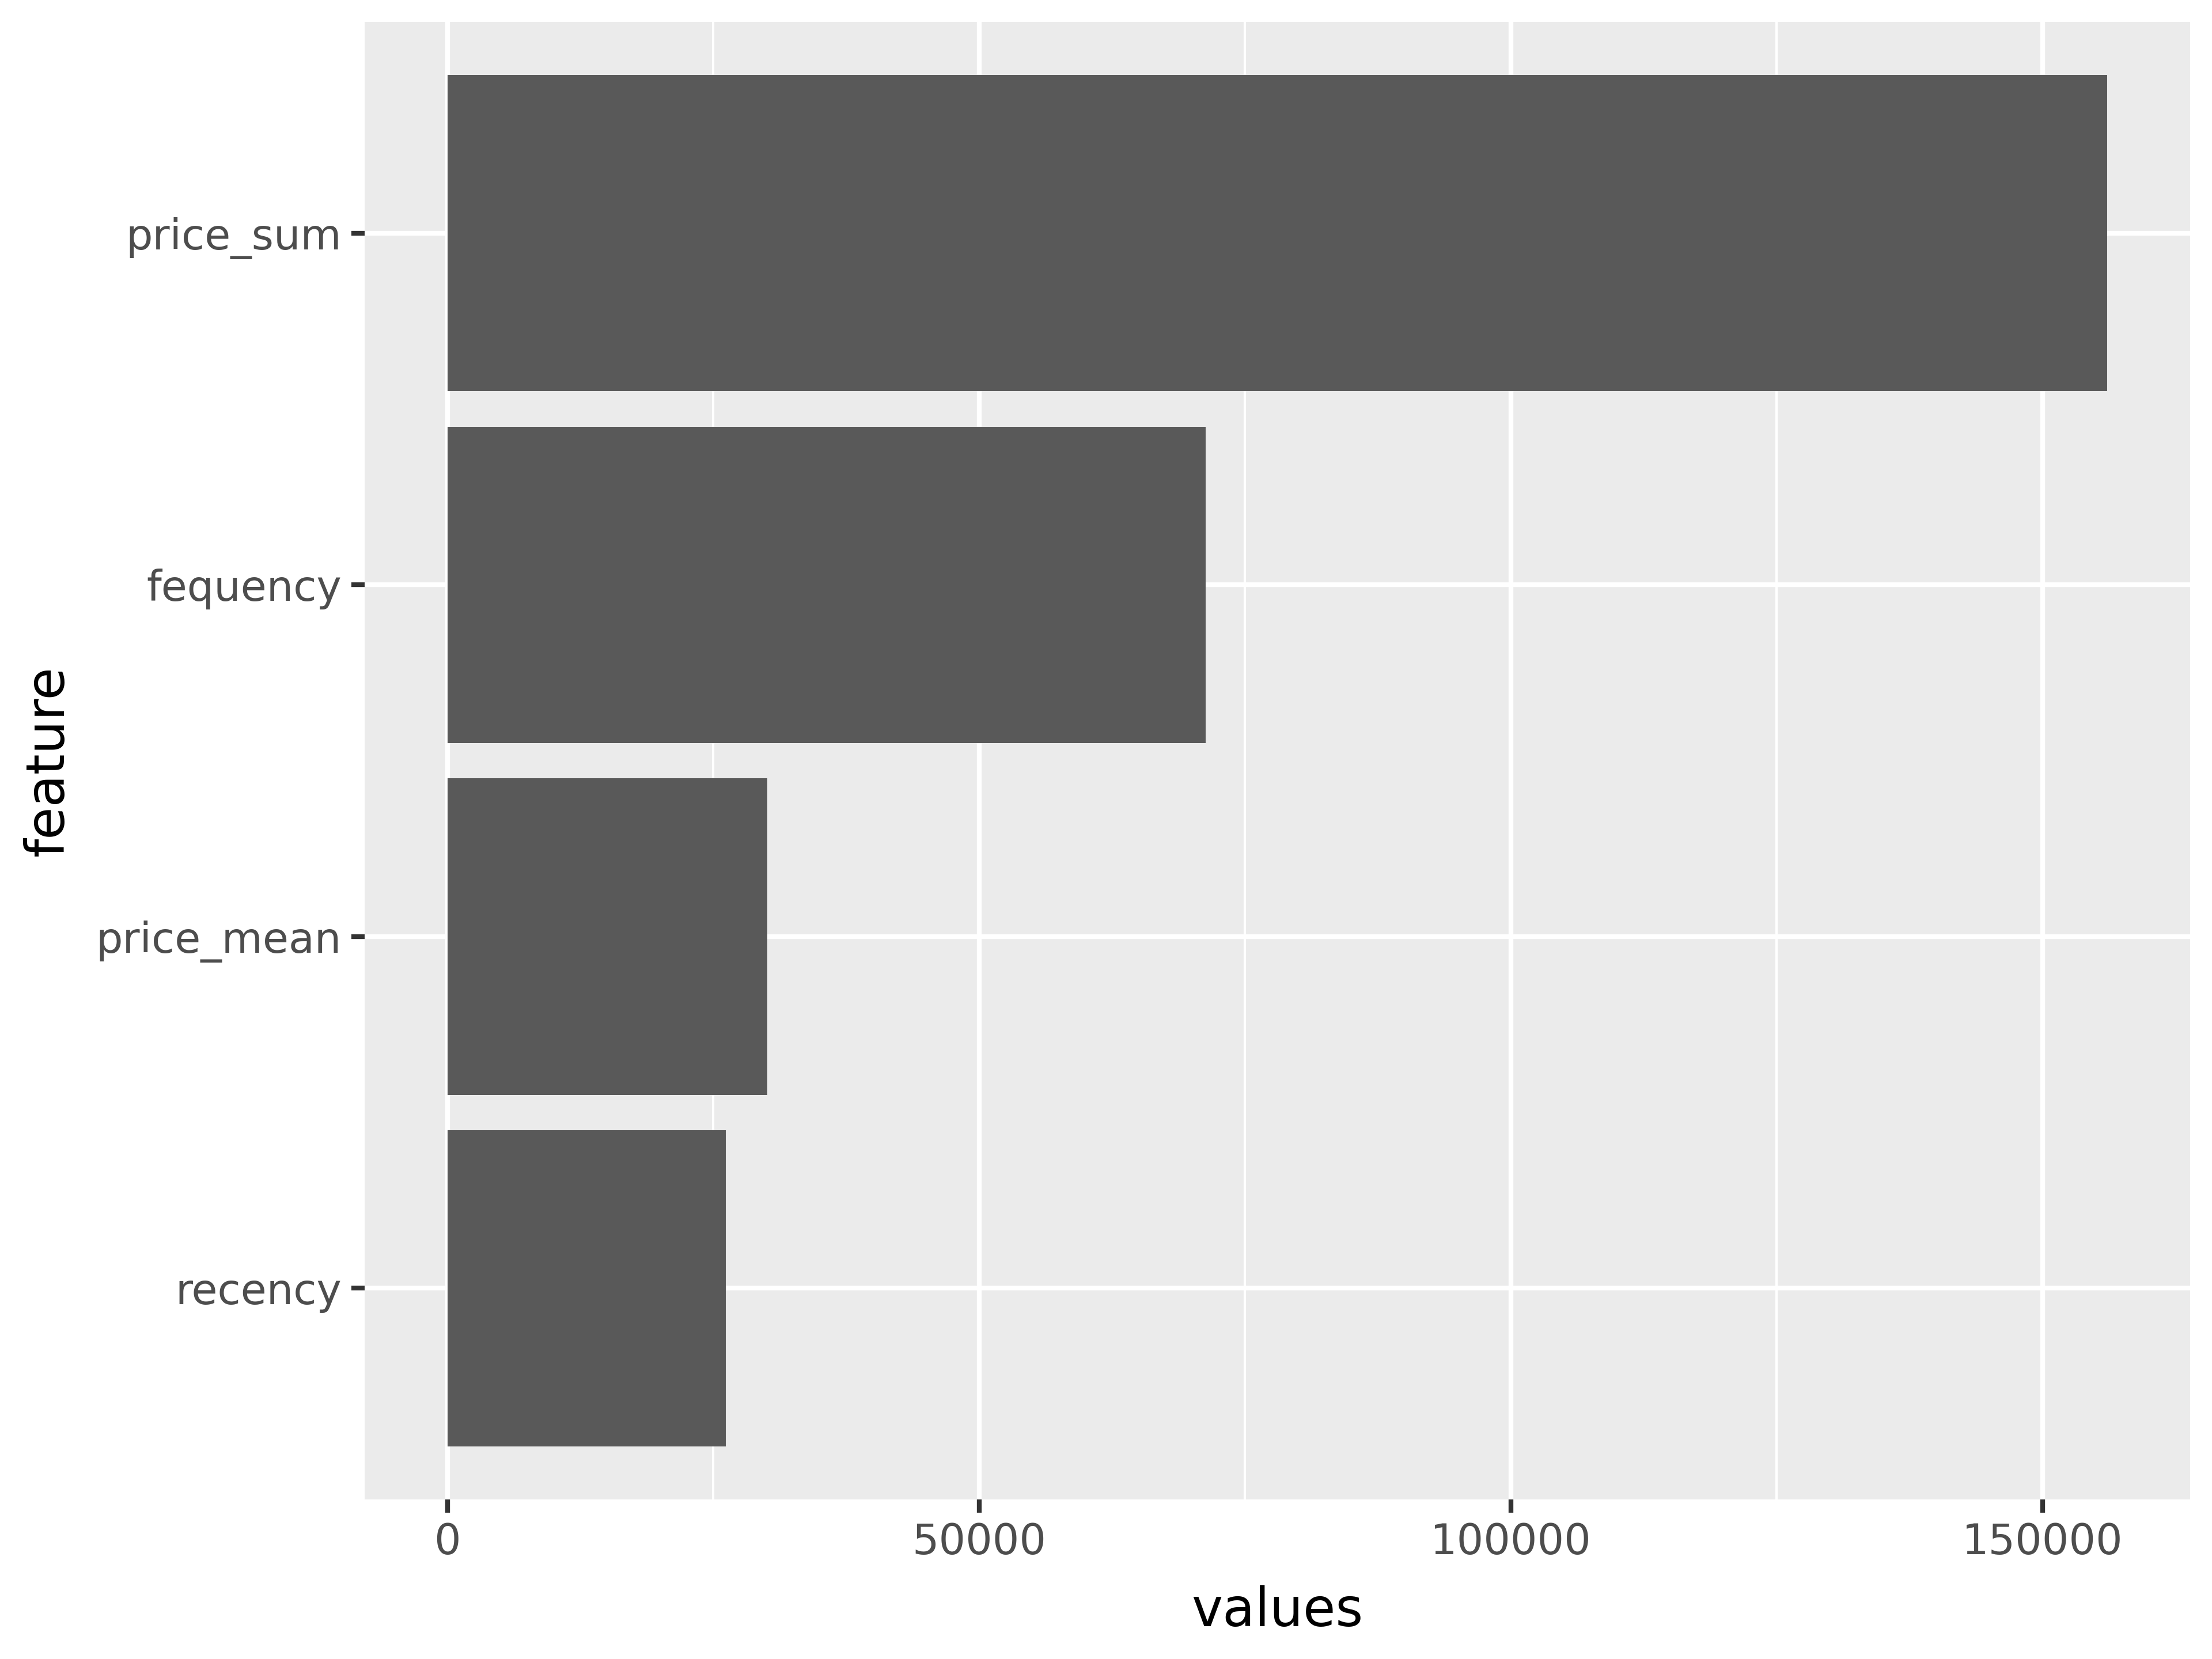

In [79]:
pn.ggplot(importancetnace_xgb_reg_model_df, pn.aes('feature','values'))+pn.geom_col()+pn.coord_flip()

In [80]:
# importancetnace | Spent Amount model
imp_amnt_proba_dict = xgb_cla_model.best_estimator_.get_booster().get_score(importance_type='gain')
print(imp_amnt_spent_dict)

importancetnace_xgb_cla_model_df = pd.DataFrame(
    data={
    'feature':list(imp_amnt_proba_dict.keys()),
    'values':list(imp_amnt_proba_dict.values())
}).assign(feature = lambda x : cat.cat_reorder(x['feature'],x['values']))
print(importancetnace_xgb_cla_model_df)

{'recency': 26198.93359375, 'fequency': 71291.4140625, 'price_sum': 156054.078125, 'price_mean': 30069.5234375}
      feature     values
0     recency  93.233498
1    fequency  58.408859
2   price_sum   3.035813
3  price_mean   3.154254


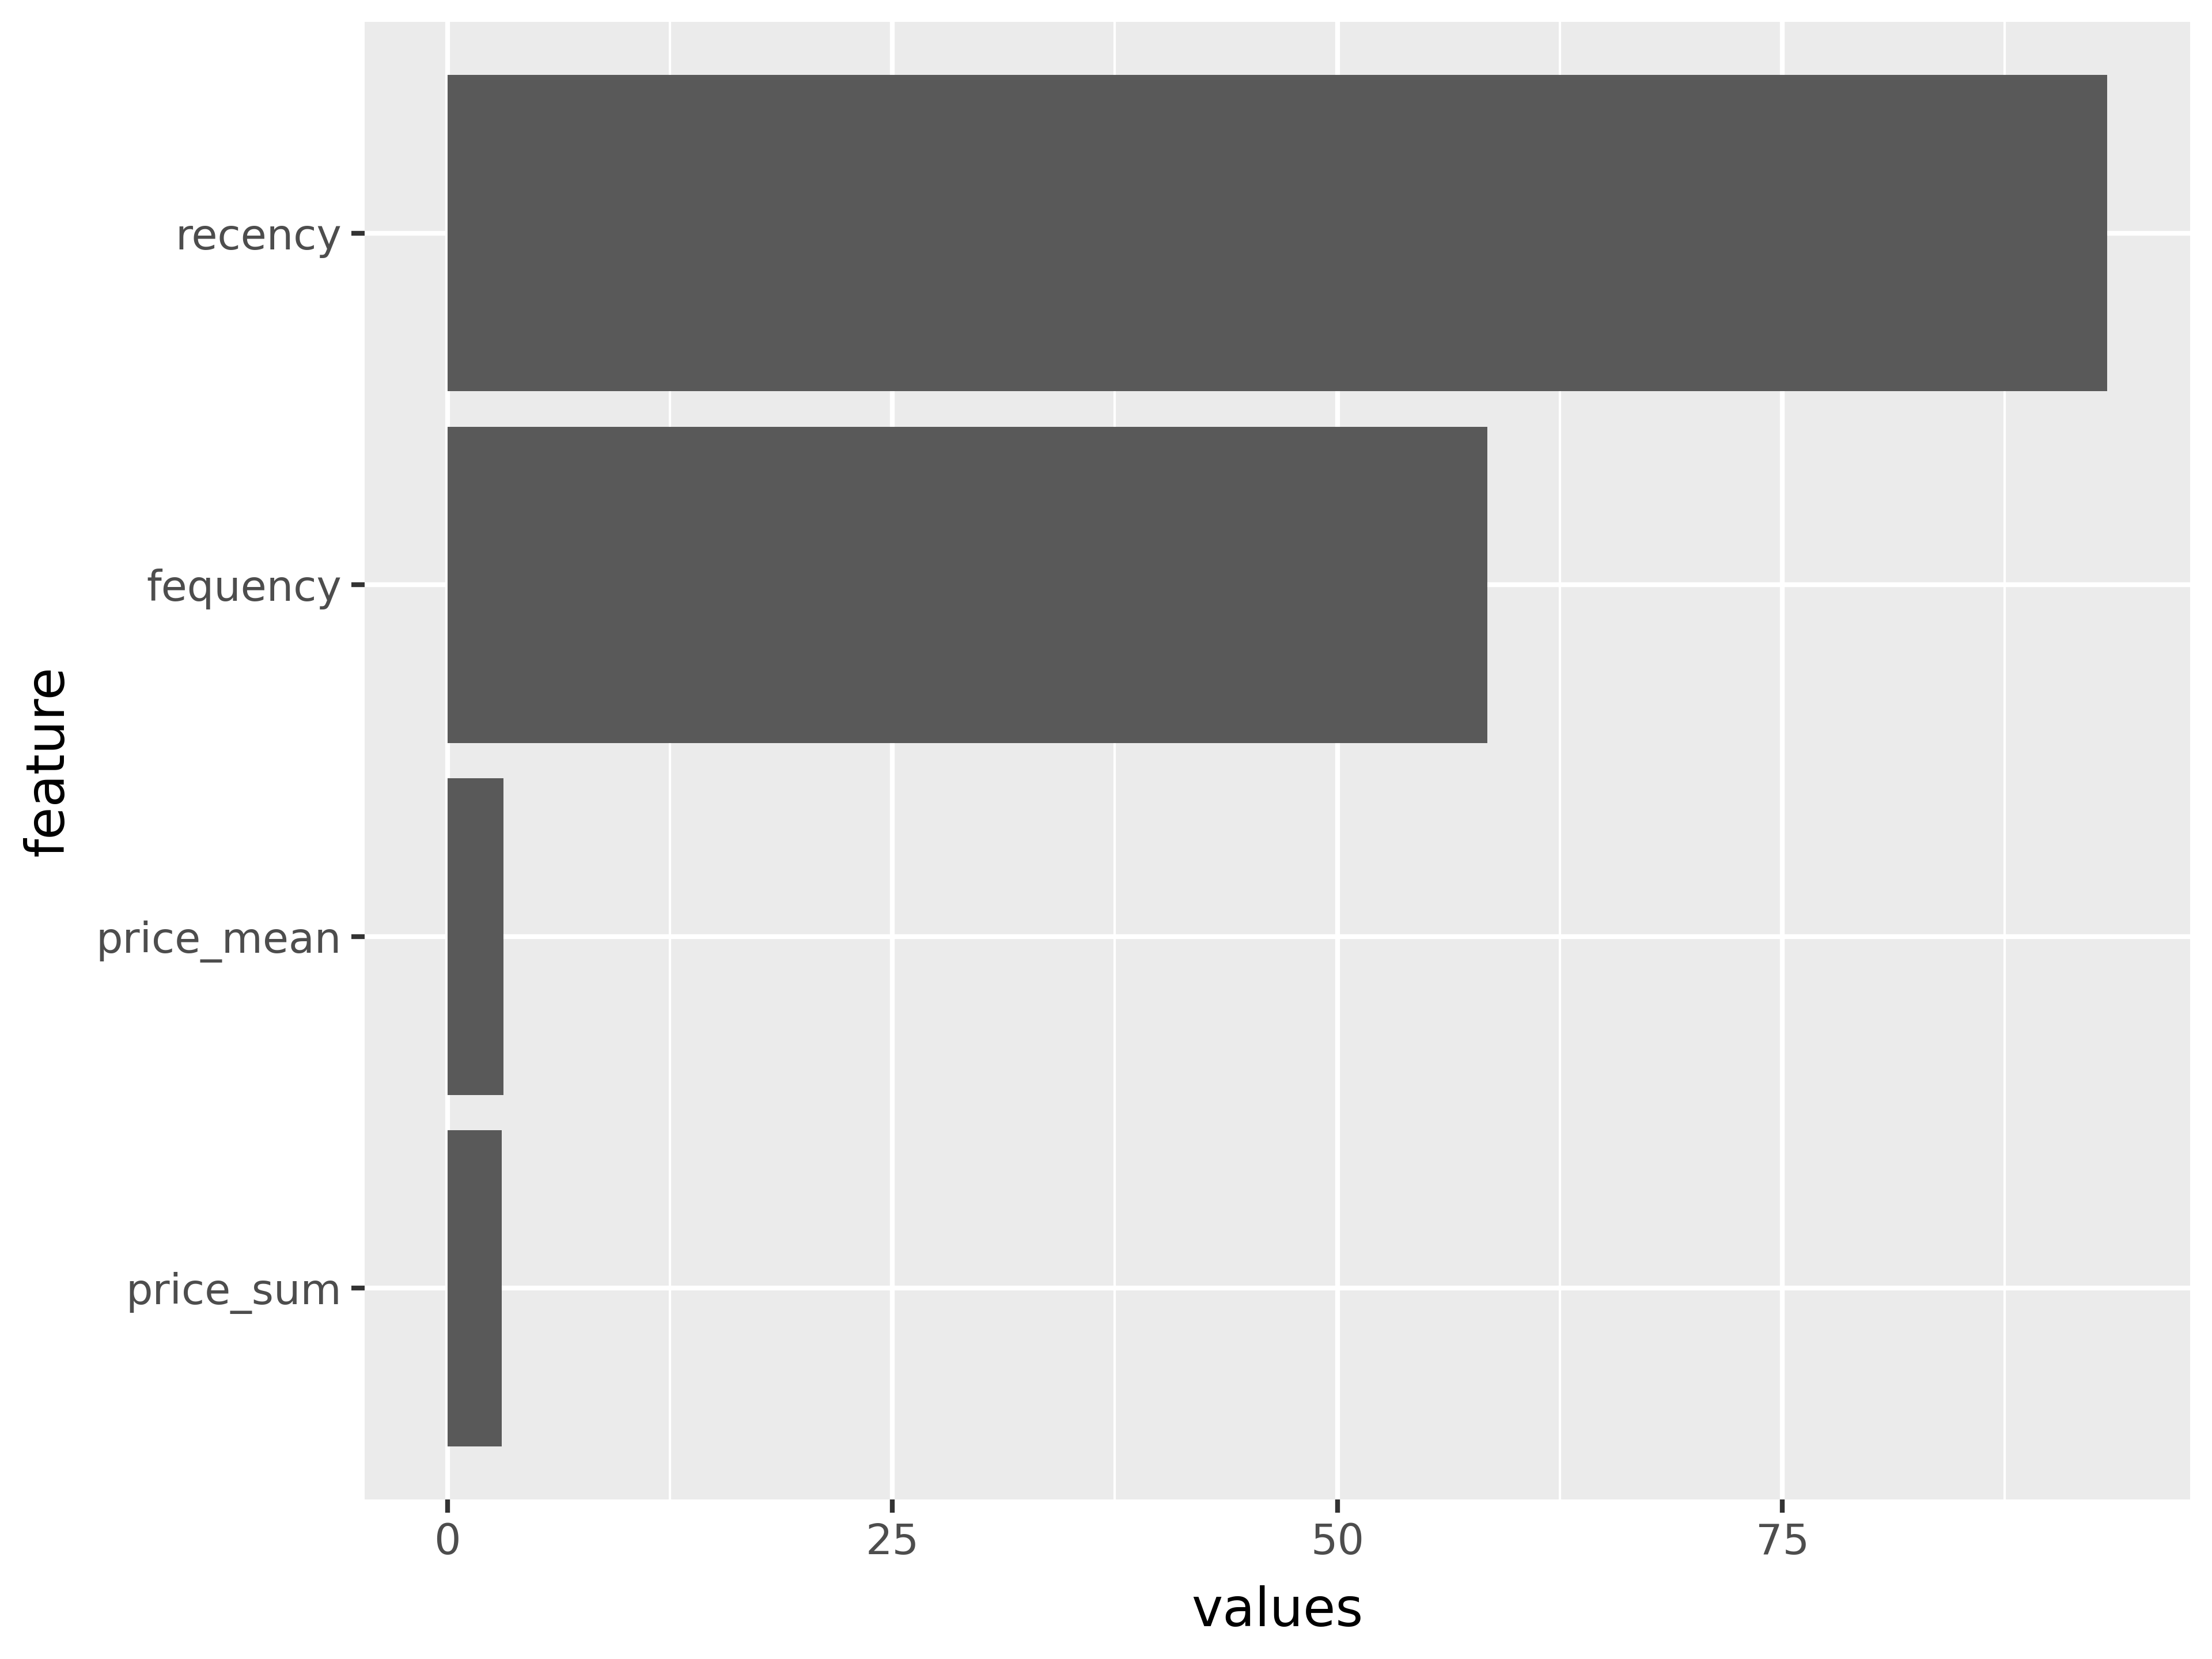

In [81]:
pn.ggplot(importancetnace_xgb_cla_model_df, pn.aes('feature','values'))+pn.geom_col()+pn.coord_flip()

## Save work

In [82]:
# prediction saved into csv file
prediction_df = pd.concat([pd.DataFrame(prediction_reg).set_axis(['Pred_spent'],axis=1),pd.DataFrame(prediction_claf)[[1]].set_axis(['Pred_prob'],axis=1),feature_df.reset_index()],axis=1)
prediction_df
prediction_df.to_csv('Predition_output.csv')
prediction_df.to_pickle('artifacts/prediction_df.pkl')

# read
temp = pd.read_pickle('artifacts/prediction_df.pkl')
temp

,Pred_spent,Pred_prob,customer_id,recency,fequency,price_sum,price_mean,spent_90_days,spent_90_flag
0,1.922816,0.061050,2,-444.0,2,89.00,44.500000,0.00,0.0
1,13.238541,0.221749,3,-127.0,5,139.47,27.894000,16.99,1.0
2,10.413027,0.220235,4,-110.0,4,100.50,25.125000,0.00,0.0
3,28.567211,0.427221,5,-88.0,11,385.61,35.055455,0.00,0.0
4,0.928312,0.067359,6,-455.0,1,20.99,20.990000,0.00,0.0
...,...,...,...,...,...,...,...,...,...
23564,0.981175,0.071608,23566,-372.0,1,36.00,36.000000,0.00,0.0
23565,1.053025,0.073598,23567,-372.0,1,20.97,20.970000,0.00,0.0
23566,4.421628,0.127325,23568,-344.0,3,121.70,40.566667,0.00,0.0
23567,1.135231,0.073598,23569,-372.0,1,25.74,25.740000,0.00,0.0


In [83]:
# save importancetnce
importancetnace_xgb_cla_model_df.to_pickle('artifacts/importancetnace_xgb_cla_model_df.pkl')
importancetnace_xgb_reg_model_df.to_pickle('artifacts/importancetnace_xgb_reg_model_df.pkl')

In [84]:
#save model
joblib.dump(xgb_reg_model,'artifacts/xgb_reg_model.pkl')
joblib.dump(xgb_cla_model,'artifacts/xgb_cla_model.pkl')

#load model
model = joblib.load('artifacts/xgb_reg_model.pkl')
model.predict(X)

array([ 1.922816 , 13.238541 , 10.413027 , ...,  4.4216275,  1.1352314,
        3.3022094], dtype=float32)

In [85]:
# which customer have highest probality to spent in next 90 days

prediction_df.sort_values('Pred_prob',ascending=False)

,Pred_spent,Pred_prob,customer_id,recency,fequency,price_sum,price_mean,spent_90_days,spent_90_flag
3617,198.200699,0.623336,3619,-3.0,20,903.35,45.167500,136.44,1.0
10077,139.872360,0.623336,10079,0.0,62,2100.38,33.877097,100.43,1.0
7590,2482.645508,0.623336,7592,-2.0,165,11478.02,69.563758,2512.91,1.0
11525,135.296280,0.623336,11527,0.0,18,700.90,38.938889,39.97,1.0
7272,85.242065,0.623336,7274,-1.0,24,725.78,30.240833,49.48,1.0
...,...,...,...,...,...,...,...,...,...
3932,1.462776,0.061050,3934,-432.0,2,126.22,63.110000,0.00,0.0
1346,1.731156,0.061050,1348,-446.0,2,116.39,58.195000,0.00,0.0
3929,1.861873,0.061050,3931,-433.0,2,66.80,33.400000,0.00,0.0
1371,1.922816,0.061050,1373,-444.0,2,87.85,43.925000,0.00,0.0


In [86]:
# which customer has recently purchased but unlike to buy

prediction_df[prediction_df['recency']>=-90][prediction_df['Pred_prob']<0.20].sort_values('Pred_prob',ascending=False)

C:\Users\saila\AppData\Local\Temp\ipykernel_51532\1994785375.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


,Pred_spent,Pred_prob,customer_id,recency,fequency,price_sum,price_mean,spent_90_days,spent_90_flag
17351,13.371201,0.199302,17353,-83.0,3,228.24,76.080000,0.00,0.0
3090,13.371201,0.199302,3092,-82.0,3,197.66,65.886667,0.00,0.0
14770,18.403322,0.199302,14772,-87.0,3,198.21,66.070000,0.00,0.0
4774,24.430452,0.199302,4776,-90.0,3,236.14,78.713333,73.45,1.0
3925,16.506195,0.199302,3927,-80.0,3,184.06,61.353333,0.00,0.0
...,...,...,...,...,...,...,...,...,...
7802,8.568181,0.115061,7804,-16.0,2,220.79,110.395000,0.00,0.0
7364,3.983781,0.112174,7366,-8.0,2,214.01,107.005000,0.00,0.0
15503,6.656785,0.112174,15505,-20.0,2,215.33,107.665000,0.00,0.0
16099,2.320918,0.112174,16101,-23.0,2,213.62,106.810000,0.00,0.0


In [87]:
# Missed opportunity :Big spender that could be unlocked
prediction_df[prediction_df['spent_90_flag']==0.0].sort_values('Pred_spent',ascending=False)

,Pred_spent,Pred_prob,customer_id,recency,fequency,price_sum,price_mean,spent_90_days,spent_90_flag
10821,128.274506,0.582114,10823,-11.0,12,618.15,51.512500,0.0,0.0
9340,120.915413,0.524485,9342,-37.0,19,906.71,47.721579,0.0,0.0
10601,118.419189,0.492922,10603,-28.0,15,1208.73,80.582000,0.0,0.0
1159,115.968269,0.582830,1161,-10.0,11,1244.34,113.121818,0.0,0.0
4238,112.828255,0.582830,4240,-8.0,11,755.19,68.653636,0.0,0.0
...,...,...,...,...,...,...,...,...,...
4860,-0.264424,0.072688,4862,-435.0,1,235.43,235.430000,0.0,0.0
14394,-0.514986,0.116963,14396,-3.0,2,139.48,69.740000,0.0,0.0
14563,-0.752991,0.135232,14565,-5.0,2,118.34,59.170000,0.0,0.0
6999,-1.945160,0.116726,7001,-6.0,2,138.50,69.250000,0.0,0.0
